In [3]:
import numpy as np#load ice cube data
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
files=["IC40_exp_new.csv","IC59_exp_new.csv","IC79_exp_new.csv","IC86_I_exp_new.csv","IC86_II_exp_new.csv", 
       "IC86_III_exp_new.csv","IC86_IV_exp_new.csv","IC86_V_exp_new.csv","IC86_VI_exp_new.csv",
       "IC86_VII_exp_new.csv"]

In [5]:
data=np.loadtxt("IC40_exp_new.csv")
for name in files[1:]:#indexing the list
    da=np.loadtxt(name)
    data=np.vstack((data,da))#load everyfile
mjd,log10_E,Ang_err,RA,Dec,Azim,Zenith=data.T
len(RA)
    

1134431

In [6]:
fields=[log10_E,RA,Dec,Ang_err]
print(Ang_err)
iceang=fields[3]

[0.48 0.62 0.56 ... 0.3  0.21 0.25]


In [7]:
print(fields)

[array([3.31, 5.17, 3.92, ..., 2.88, 2.98, 3.28]), array([203.024,  75.024,  97.501, ..., 308.127, 332.199, 213.309]), array([ 16.76 , -13.371,  11.29 , ...,  42.543,  44.72 ,   4.708]), array([0.48, 0.62, 0.56, ..., 0.3 , 0.21, 0.25])]


In [8]:
df=pd.read_csv("TabO1.csv")
#print(df)
df.loc[31, 'RA'] = '08 43 00.0'
df.loc[31, 'Decl'] = '+73 30 00'
df.loc[32, 'RA'] = '00 47 30.0'
df.loc[32, 'Decl'] = '-25 11 37 '
df.loc[33,'RA']='09 52 34.1'
df.loc[33,'Decl']='+68 50 42'
df.loc[34,'RA']='00 44 18.0'
df.loc[34,'Decl']='+42 18 00'
df.loc[35,'RA']='13 42 06.24'
df.loc[35,'Decl']='-26 53 48.1'
df.loc[36,'RA']='00 49 12.0 '
df.loc[36,'Decl']='-26 06 00  '

df.to_csv("updated_file.csv", index=False)
print(df)

#df.loc[1, 'RA'] = '09 55 59.28'
#df.loc[1, 'Decl'] = '+69 41 02.40'


                     Name     Period    Period_Err Pdot_lim          Pdot  \
0   CXOU J010043.1-721134   8.020392  9.000000e-06      NaN  1.880000e-11   
1              4U 0142+61   8.688692  5.000000e-08      NaN  2.022000e-12   
2           SGR 0418+5729   9.078388  5.000000e-08      NaN  4.000000e-15   
3           SGR 0501+4516   5.762069  1.000000e-07      NaN  5.940000e-12   
4             SGR 0526-66   8.054400  2.000000e-04      NaN  3.800000e-11   
5          1E 1048.1-5937   6.457875  3.000000e-06      NaN  2.250000e-11   
6          1E 1547.0-5408   2.072125  1.000000e-07      NaN  4.770000e-11   
7          PSR J1622-4950   4.326100  1.000000e-04      NaN  1.700000e-11   
8             SGR 1627-41   2.594578  6.000000e-06      NaN  1.900000e-11   
9   CXOU J164710.2-455216  10.610644  1.700000e-05        <  4.000000e-13   
10  1RXS J170849.0-400910  11.005025  1.700000e-07      NaN  1.945500e-11   
11  CXOU J171405.7-381031   3.825352  4.000000e-06      NaN  6.400000e-11   

In [9]:
df1=df.rename({'RA':'RA_M'},axis=1)
print(df1)

                     Name     Period    Period_Err Pdot_lim          Pdot  \
0   CXOU J010043.1-721134   8.020392  9.000000e-06      NaN  1.880000e-11   
1              4U 0142+61   8.688692  5.000000e-08      NaN  2.022000e-12   
2           SGR 0418+5729   9.078388  5.000000e-08      NaN  4.000000e-15   
3           SGR 0501+4516   5.762069  1.000000e-07      NaN  5.940000e-12   
4             SGR 0526-66   8.054400  2.000000e-04      NaN  3.800000e-11   
5          1E 1048.1-5937   6.457875  3.000000e-06      NaN  2.250000e-11   
6          1E 1547.0-5408   2.072125  1.000000e-07      NaN  4.770000e-11   
7          PSR J1622-4950   4.326100  1.000000e-04      NaN  1.700000e-11   
8             SGR 1627-41   2.594578  6.000000e-06      NaN  1.900000e-11   
9   CXOU J164710.2-455216  10.610644  1.700000e-05        <  4.000000e-13   
10  1RXS J170849.0-400910  11.005025  1.700000e-07      NaN  1.945500e-11   
11  CXOU J171405.7-381031   3.825352  4.000000e-06      NaN  6.400000e-11   

[37 rows x 47 columns]


In [10]:
import re
def convert_ra_to_comma(ra):#replacing space with comma
    return re.sub(r"\s+", ",",ra.strip())
df1['RA_M_comma'] = df1['RA_M'].apply(convert_ra_to_comma)# Apply the function to the entire RA_M column
def convert_dec_to_comma(dec):
    return re.sub(r"\s+", ",",dec.strip())
df1['dec_M_comma'] = df1['Decl'].apply(convert_dec_to_comma)
    
print(df1[['Name', 'RA_M', 'RA_M_comma', 'Decl','dec_M_comma']])# Show the DataFrame with the new RA_M_Comma column

                     Name            RA_M      RA_M_comma            Decl  \
0   CXOU J010043.1-721134     01 00 43.14     01,00,43.14     -72 11 33.8   
1              4U 0142+61    01 46 22.407    01,46,22.407    +61 45 03.19   
2           SGR 0418+5729    04 18 33.867    04,18,33.867    +57 32 22.91   
3           SGR 0501+4516     05 01 06.76     05,01,06.76    +45 16 33.92   
4             SGR 0526-66     05 26 00.89     05,26,00.89     -66 04 36.3   
5          1E 1048.1-5937     10 50 07.14     10,50,07.14     -59 53 21.4   
6          1E 1547.0-5408  15 50 54.12386  15,50,54.12386  -54 18 24.1141   
7          PSR J1622-4950     16 22 44.89     16,22,44.89     -49 50 52.7   
8             SGR 1627-41    16 35 51.844    16,35,51.844    -47 35 23.31   
9   CXOU J164710.2-455216     16 47 10.20     16,47,10.20    -45 52 16.90   
10  1RXS J170849.0-400910     17 08 46.87     17,08,46.87    -40 08 52.44   
11  CXOU J171405.7-381031     17 14 05.74     17,14,05.74     -38 10 30.9   

In [11]:
def ra_to_degrees(ra_string):
    ra_parts = ra_string.split(',')
    ra_hours = int(ra_parts[0])  # Convert to integer (handles leading zeros)
    ra_minutes = int(ra_parts[1])  # Convert to integer (handles leading zeros)
    ra_seconds = float(ra_parts[2])  # Convert to float
    return (ra_hours * 15) + (ra_minutes / 4) + (ra_seconds / 240)
#field3.loc[:,'RA_M(deg)']=field3['RA_M_comma'].apply(ra_to_degrees)
def dec_to_degrees(dec_string):
    dec_parts = dec_string.split(',')
    dec_degrees = int(dec_parts[0])  # Convert to integer (handles leading zeros)
    dec_minutes = int(dec_parts[1])  # Convert to integer (handles leading zeros)
    dec_seconds = float(dec_parts[2])
    sign = 1 if dec_degrees >= 0 else -1
    return abs(dec_degrees) + (dec_minutes / 60) + (dec_seconds / 3600) * sign
df1['RA_M(deg)'] = df1['RA_M_comma'].apply(ra_to_degrees)
df1['Decl_M(deg)'] = df1['dec_M_comma'].apply(dec_to_degrees)
print(df1)

                     Name     Period    Period_Err Pdot_lim          Pdot  \
0   CXOU J010043.1-721134   8.020392  9.000000e-06      NaN  1.880000e-11   
1              4U 0142+61   8.688692  5.000000e-08      NaN  2.022000e-12   
2           SGR 0418+5729   9.078388  5.000000e-08      NaN  4.000000e-15   
3           SGR 0501+4516   5.762069  1.000000e-07      NaN  5.940000e-12   
4             SGR 0526-66   8.054400  2.000000e-04      NaN  3.800000e-11   
5          1E 1048.1-5937   6.457875  3.000000e-06      NaN  2.250000e-11   
6          1E 1547.0-5408   2.072125  1.000000e-07      NaN  4.770000e-11   
7          PSR J1622-4950   4.326100  1.000000e-04      NaN  1.700000e-11   
8             SGR 1627-41   2.594578  6.000000e-06      NaN  1.900000e-11   
9   CXOU J164710.2-455216  10.610644  1.700000e-05        <  4.000000e-13   
10  1RXS J170849.0-400910  11.005025  1.700000e-07      NaN  1.945500e-11   
11  CXOU J171405.7-381031   3.825352  4.000000e-06      NaN  6.400000e-11   

In [12]:
field3=df1[['RA_M(deg)','Decl_M(deg)']]
#print(field3)
#field3.loc[32, 'RA_M(deg)'] = 11.07
#field3.loc[32, 'Decl_M(deg)'] = 25.02
#field3.to_csv("updated_file.csv", index=False)
print(field3)


     RA_M(deg)  Decl_M(deg)
0    15.179750    72.173944
1    26.593363    61.750886
2    64.641113    57.539697
3    75.278167    45.276089
4    81.503708    66.056583
5   162.529750    59.877389
6   237.725516    54.293302
7   245.687042    49.818694
8   248.966017    47.576858
9   251.792500    45.861972
10  257.195292    40.118767
11  258.523917    38.158083
12  266.417350    28.991717
13  272.163904    20.388931
14  272.462862    19.702241
15  274.515417    16.107833
16  275.575000    16.059222
17  278.434875     8.514583
18  278.717158     8.734439
19  280.330596     4.930233
20  283.194458     0.554944
21  286.809708     9.322250
22  293.731657    21.896607
23  345.284562    58.879014
24  118.927000    29.536333
25  270.245833    22.920000
26  272.046667    20.619722
27  274.714083    15.977050
28  281.227833     2.918583
29  303.487083    34.330000
30  281.603917     2.958306
31  130.750000    73.500000
32   11.875000    25.173056
33  148.142083    68.845000
34   11.075000    42

In [13]:
ra_mag=np.array(field3['RA_M(deg)'])
dec_mag=np.array(field3['Decl_M(deg)'])
ice_ra=(fields[1])
ice_dec=(fields[2])
print(ice_ra)
print(ice_dec)
print(ra_mag)
#print(dec_mag)|
print(dec_mag)

[203.024  75.024  97.501 ... 308.127 332.199 213.309]
[ 16.76  -13.371  11.29  ...  42.543  44.72    4.708]
[ 15.17975     26.5933625   64.6411125   75.27816667  81.50370833
 162.52975    237.72551608 245.68704167 248.96601667 251.7925
 257.19529167 258.52391667 266.41735    272.16390417 272.46286233
 274.51541667 275.575      278.434875   278.71715833 280.33059583
 283.19445833 286.80970833 293.7316575  345.2845625  118.927
 270.24583333 272.04666667 274.71408333 281.22783333 303.48708333
 281.60391667 130.75        11.875      148.14208333  11.075
 205.526       12.3       ]
[72.17394444 61.75088611 57.53969722 45.27608889 66.05658333 59.87738889
 54.29330164 49.81869444 47.57685833 45.86197222 40.11876667 38.15808333
 28.99171722 20.38893056 19.70224125 16.10783333 16.05922222  8.51458333
  8.73443889  4.93023333  0.55494444  9.32225    21.89660733 58.87901389
 29.53633333 22.92       20.61972222 15.97705     2.91858333 34.33
  2.95830556 73.5        25.17305556 68.845      42.3    

In [14]:
ice_ra=(fields[1])
ice_dec=(fields[2])
print(ice_ra)
print(ice_dec)
#len(ice_ra)
np.random.seed(0)
N=1000
random_ra=np.random.uniform(0,360,N)
#print(random_ra)
random_dec=np.random.uniform(np.sin(np.radians(-85)),np.sin(np.radians(85)),N)
random_dec = np.degrees(np.arcsin(random_dec))

print(random_dec)

[203.024  75.024  97.501 ... 308.127 332.199 213.309]
[ 16.76  -13.371  11.29  ...  42.543  44.72    4.708]
[ 10.66426129 -77.45979726  -2.76064081  24.5792773  -65.30964589
  49.1263568    2.29301628 -69.24526874 -33.30360446  64.6753554
   9.4399003  -51.4502649  -25.04273197  -4.94866984 -72.64098636
 -10.14246308  -1.20344327 -30.71003336  10.17197985  30.30167929
 -31.75722108  13.89142282  16.15172333  63.33771249  33.67177234
  43.95072088  -1.09368659 -38.82237722  81.06203374 -47.60104607
  -3.26006286 -59.37577555  62.16841527  67.86695964  25.91953331
 -17.38990552 -29.29891251 -27.87908437 -47.95126741   2.94753397
 -45.5318088  -21.41643738  14.62245747  26.95917242 -71.41178914
  -8.00364922  17.64337653  44.73296451  -2.81794784  69.20244085
 -27.83657538 -75.76145293  -1.85502397 -29.0725226   40.16355045
 -32.1691713  -22.16655927  35.46731537  25.3818613    6.64173284
  24.10036938  -9.32921816 -80.26996691 -76.79798222   1.28113556
 -56.12408155 -63.43562298  68.0469

In [15]:
for i in range(0,1001):
    ra_mag0=random_ra[i]
    dec_mag0=random_dec[i]
    ra_mag1=np.radians(ra_mag0)
    dec_mag1=np.radians(dec_mag0)
    ice_ra1=np.radians(ice_ra)
    ice_dec1=np.radians(ice_dec)
    RA_diff=(ice_ra1-ra_mag1)
    Ang_sep=np.arccos(np.sin(ice_dec1)*np.sin(dec_mag1)+np.cos(ice_dec1)*np.cos(dec_mag1)*np.cos(RA_diff))
    def sig( declcut):
        decdiff=np.abs(ice_dec-dec_mag0)
        nuind=np.nonzero(decdiff < declcut)
        sg=np.radians(iceang[nuind])**2
        Ang_sep1=(np.arccos((np.sin(ice_dec1[nuind])*np.sin(dec_mag1)+np.cos(ice_dec1[nuind])*np.cos(dec_mag1)*np.cos(ice_ra1[nuind]-ra_mag1))))**2
        return ((np.exp(-1*Ang_sep1/(2*sg)))/(2*np.pi*sg))
    def bgs(band, twopi = True):
        if twopi == True:
            s_ang = (np.sin(np.radians(dec_mag0 + band)) - np.sin(np.radians(dec_mag0 - band)))*(2 * np.pi)
            return 1/s_ang
        else:
            s_ang = (np.sin(np.deg2rad(dec_mag0 + band)) - np.sin(np.deg2rad(dec_mag0- band)))
            return 1/s_ang
    def P(x,N,S,B):
        nsN=x/N
        return nsN*S+(1-nsN)*B
    def TS(x,N,S,B):
        return 2*np.sum(np.log((P(x,N,S,B)/B)))
    declcut=5
    band=5
    B=bgs(band,twopi=True)
    S =(sig(declcut)) 
    decdiff=np.abs(random_dec-dec_mag0)
    nuind=np.nonzero(decdiff < declcut)
    N=len(nuind[0])
    def ns_for_TSmax(S, B, N):
        declcut=5
        band=5
        B=bgs(band,twopi=True)
        S =(sig(declcut)) 
        nll = lambda x: -TS(x,N,S,B)
        soln = minimize(nll,6,bounds=((0,None),))
        ns = float(soln.x)
        return ns
    ns1=ns_for_TSmax(S, B, N)
    print(i,N,ns1,TS(ns1,N,S,B),sep="|")
    
    #plt.hist(TS_values,ns_v)
    #plt.plot(ns_v,TS_values)
#plt.text(x=3.5, y=5, s="V388 Cas", fontsize=12, color='black')
   # plt.xlabel(r'$n_s$ (Number of signal events)')
   # plt.xlabel('TS ')
   # plt.grid(True)

0|80|0.0|0.0
1|22|0.0|0.0
2|73|0.0|0.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_10740\2561338765.py:27: RuntimeWarning: invalid value encountered in log
  return 2*np.sum(np.log((P(x,N,S,B)/B)))


3|75|0.0|0.0
4|38|0.0|0.0
5|56|0.0|0.0
6|86|0.0013601522274867641|0.05467215301313942
7|37|0.0005802808302383792|0.00985485056328861
8|57|0.0|0.0
9|54|0.0|0.0
10|81|0.0|0.0
11|63|0.0|0.0
12|86|0.0|0.0
13|77|0.0|0.0
14|30|0.0|0.0
15|73|0.0|0.0
16|79|0.0|0.0
17|59|0.0|0.0
18|84|0.0|0.0
19|73|0.0|0.0
20|57|0.0|0.0
21|79|0.0|0.0
22|78|0.0|0.0
23|53|0.0|0.0
24|80|0.00011249582852960854|0.00010938556121749179
25|66|0.0|0.0
26|80|0.0|0.0
27|61|0.0|0.0
28|14|0.0|0.0
29|73|0.0|0.0
30|75|0.0|0.0
31|33|0.0|0.0
32|52|0.0|0.0
33|43|0.0|0.0
34|75|0.0|0.0
35|74|0.0|0.0
36|65|0.0|0.0
37|69|0.0|0.0
38|75|0.0|0.0
39|85|0.0|0.0
40|65|0.0|0.0
41|88|0.0|0.0
42|82|0.0|0.0
43|77|0.0|0.0
44|31|0.0|0.0
45|75|0.0|0.0
46|73|0.0|0.0
47|62|0.0|0.0
48|74|0.0|0.0
49|44|0.0|0.0
50|71|0.0|0.0
51|26|0.0|0.0
52|77|0.0|0.0
53|67|3.586494397820296e-05|5.359036439523974e-05
54|75|0.0|0.0
55|59|0.0|0.0
56|86|0.0|0.0
57|87|0.0|0.0
58|75|0.0|0.0
59|82|0.0|0.0
60|80|0.0|0.0
61|77|0.0|0.0
62|16|0.0|0.0
63|22|0.0|0.0
64|81|0.0|0

459|85|0.0|0.0
460|27|0.0|0.0
461|53|0.0|0.0
462|77|0.0|0.0
463|77|0.001378567902629255|0.016050684553878532
464|80|0.0|0.0
465|84|0.0|0.0
466|87|0.0|0.0
467|66|0.0|0.0
468|82|0.0|0.0
469|63|0.0|0.0
470|25|0.0|0.0
471|77|0.0|0.0
472|76|0.0|0.0
473|54|0.0|0.0
474|86|0.0|0.0
475|73|0.0|0.0
476|88|0.0|0.0
477|66|0.0003573325166659141|0.00466305378261006
478|77|0.0|0.0
479|73|0.004431123686654679|0.14225139991470048
480|38|0.0|0.0
481|91|0.0|0.0
482|37|0.0|0.0
483|54|0.0|0.0
484|80|0.0|0.0
485|41|0.0|0.0
486|81|0.0|0.0
487|85|0.0|0.0
488|73|0.0|0.0
489|75|0.0|0.0
490|77|0.0|0.0
491|75|0.0006593698812576006|0.011113142445040573
492|75|0.0|0.0
493|53|0.0|0.0
494|27|0.0|0.0
495|37|0.0|0.0
496|66|0.0|0.0
497|63|0.0|0.0
498|38|0.0|0.0
499|60|0.0|0.0
500|76|0.0|0.0
501|66|0.0|0.0
502|57|0.0|0.0
503|80|0.0|0.0
504|49|0.0|0.0
505|80|0.0|0.0
506|86|0.0|0.0
507|80|0.0|0.0
508|32|0.0|0.0
509|84|0.0|0.0
510|37|0.0|0.0
511|65|0.00021256518730316065|0.002473602887867136
512|72|0.0|0.0
513|76|0.000530470

917|87|0.0|0.0
918|72|0.0|0.0
919|72|0.0|0.0
920|40|0.0|0.0
921|81|0.0|0.0
922|61|0.0|0.0
923|21|0.0|0.0
924|49|0.0004494720123858304|0.0015786230075091542
925|79|0.0|0.0
926|57|0.0|0.0
927|63|0.0|0.0
928|27|0.0|0.0
929|77|0.0|0.0
930|38|0.0|0.0
931|68|0.0|0.0
932|78|0.0|0.0
933|55|0.0|0.0
934|61|0.0|0.0
935|75|0.0|0.0
936|25|0.0|0.0
937|76|0.0|0.0
938|77|0.0|0.0
939|39|0.0|0.0
940|75|0.0017729922631670892|0.061787344306443906
941|52|0.0|0.0
942|65|0.0|0.0
943|79|0.0007728302106271594|0.012444687529752283
944|76|0.0|0.0
945|62|0.0|0.0
946|18|0.0|0.0
947|21|0.0|0.0
948|80|0.0|0.0
949|51|0.0|0.0
950|77|0.0|0.0
951|74|0.0|0.0
952|80|0.0|0.0
953|81|0.0|0.0
954|77|0.0|0.0
955|56|0.0|0.0
956|69|0.0|0.0
957|9|0.0|0.0
958|84|0.0|0.0
959|60|0.0|0.0
960|77|0.0|0.0
961|41|0.0|0.0
962|79|0.0|0.0
963|68|0.0|0.0
964|80|0.0|0.0
965|74|0.00020927412314844597|0.002212882115948566
966|59|0.0|0.0
967|64|0.0|0.0
968|41|0.0|0.0
969|85|0.0|0.0
970|51|0.0014194012406901922|0.01244210431281273
971|35|0.0|0.0


IndexError: index 1000 is out of bounds for axis 0 with size 1000

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.        , 0.05050505, 0.1010101 , 0.15151515, 0.2020202 ,
        0.25252525, 0.3030303 , 0.35353535, 0.4040404 , 0.45454545,
        0.50505051, 0.55555556, 0.60606061, 0.65656566, 0.70707071,
        0.75757576, 0.80808081, 0.85858586, 0.90909091, 0.95959596,
        1.01010101, 1.06060606, 1.11111111, 1.16161616, 1.21212121,
        1.26262626, 1.31313131, 1.36363636, 1.41414141, 1.46464646,
        1.51515152, 1.56565657, 1.61616162, 1.66666667, 1.71717172,
        1.76767677, 1.81818182, 1.86868687, 1.91919192, 1.96969697,
        2.

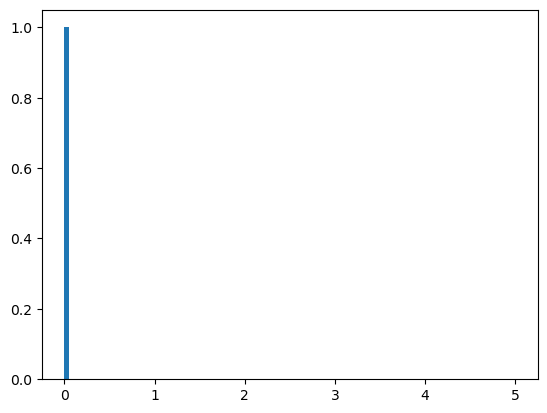

In [16]:
ns_v=np.linspace(0,5, 100)
TS_values =( [TS(x, N, S, B) for x in ns_v])

plt.hist(TS_values,ns_v)
#print(B)
#print(Ang_sep)
#print(TS(x,N,S,B))